<a href="https://colab.research.google.com/github/brightliam20-ops/MACHINE-LEARNING-ASSIGNMENT/blob/main/Wine_quality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
data = pd.read_csv("/content/sample_data/winequality.csv")

In [ ]:
data.isna().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [ ]:
X = data.drop("quality", axis=1)  # Input features
y = data["quality"]               # Output (target)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
scaler

StandardScaler()

In [ ]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)  # Regression output
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='mse',  # Mean Squared Error
    metrics=['mae']
)


In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    verbose=1
)


Epoch 1/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 12.7395 - mae: 2.9352 - val_loss: 3.1183 - val_mae: 1.3142
Epoch 2/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 2.3014 - mae: 1.1671 - val_loss: 2.5365 - val_mae: 1.1497
Epoch 3/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.7922 - mae: 1.0315 - val_loss: 2.0122 - val_mae: 1.0204
Epoch 4/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.4237 - mae: 0.9186 - val_loss: 1.5432 - val_mae: 0.9107
Epoch 5/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.1307 - mae: 0.8244 - val_loss: 1.2431 - val_mae: 0.8045
Epoch 6/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9018 - mae: 0.7361 - val_loss: 0.9618 - val_mae: 0.7202
Epoch 7/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7377 - mae: 0.6672 - val_loss: 0.7682 - val_mae: 0.6529
Epoch 8/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6336 - mae: 0.6186 - val_loss: 0.6594 - val_mae: 0.6137
Epoch 9/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - l

In [ ]:
y_pred = model.predict(X_test)


31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


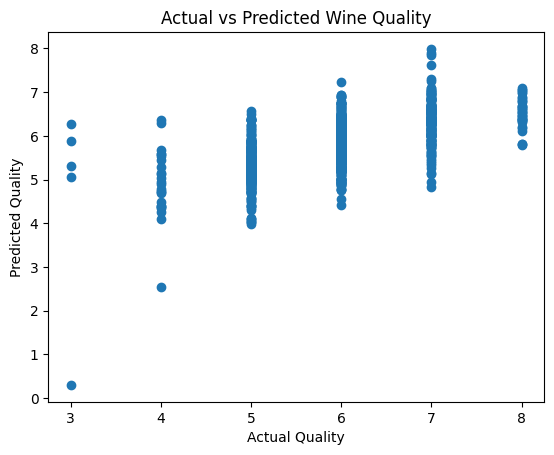

In [ ]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality")
plt.title("Actual vs Predicted Wine Quality")
plt.show()

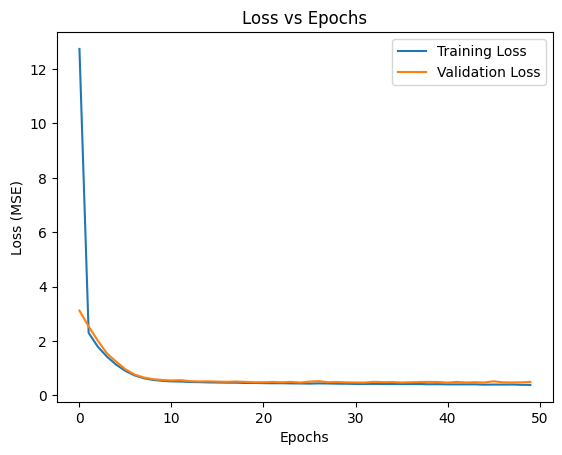

In [ ]:
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.title("Loss vs Epochs")
plt.legend()
plt.show()